In [1]:
!pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 36.8 MB/s eta 0:00:00


In [2]:
import os

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import MNIST

import matplotlib.pyplot as plt

import pytorch_lightning as pl


random_seed = 42
torch.manual_seed(random_seed)

BATCH_SIZE=128
AVAIL_GPUS = min(1, torch.cuda.device_count())
NUM_WORKERS=int(os.cpu_count() / 2)

In [3]:
class MNISTDataModule(pl.LightningDataModule):
    def __init__(self, data_dir="./data",
                 batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers

        self.transform = transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Normalize((0.1307,), (0.3081,)),
            ]
        )

    def prepare_data(self):
        MNIST(self.data_dir, train=True, download=True)
        MNIST(self.data_dir, train=False, download=True)

    def setup(self, stage=None):
        # Assign train/val datasets
        if stage == "fit" or stage is None:
            mnist_full = MNIST(self.data_dir, train=True, transform=self.transform)
            self.mnist_train, self.mnist_val = random_split(mnist_full, [55000, 5000])

        # Assign test dataset
        if stage == "test" or stage is None:
            self.mnist_test = MNIST(self.data_dir, train=False, transform=self.transform)

    def train_dataloader(self):
        return DataLoader(self.mnist_train, batch_size=self.batch_size, num_workers=self.num_workers)

    def val_dataloader(self):
        return DataLoader(self.mnist_val, batch_size=self.batch_size, num_workers=self.num_workers)

    def test_dataloader(self):
        return DataLoader(self.mnist_test, batch_size=self.batch_size, num_workers=self.num_workers)

In [4]:
# WGAN Critic
class Critic(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)

        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 1)

    def forward(self, x):
        x = F.leaky_relu(F.max_pool2d(self.conv1(x), 2), 0.2)
        x = F.leaky_relu(F.max_pool2d(self.conv2(x), 2), 0.2)
        x = x.view(-1, 320)
        x = F.leaky_relu(self.fc1(x), 0.2)

        x = self.fc2(x)

        return x

In [5]:
# Generator
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.lin1 = nn.Linear(latent_dim, 7 * 7 * 64)

        self.ct1 = nn.ConvTranspose2d(
            64, 32,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.ct2 = nn.ConvTranspose2d(
            32, 16,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.conv = nn.Conv2d(
            16, 1,
            kernel_size=3,
            padding=1
        )

    def forward(self, x):

        x = self.lin1(x)
        x = x.view(-1, 64, 7, 7)
        x = F.relu(self.ct1(x))
        x = F.relu(self.ct2(x))
        x = torch.tanh(self.conv(x))

        return x

In [6]:

class WGAN(pl.LightningModule):

    def __init__(self, latent_dim=100, lr=0.00005):
        super().__init__()

        self.save_hyperparameters()

        self.automatic_optimization = False

        self.generator = Generator(latent_dim)

        # Replace discriminator with critic
        self.critic = Critic()

        self.validation_z = torch.randn(6, latent_dim)

        # Number of critic updates
        self.critic_iterations = 5

        # Weight clipping value
        self.weight_clip = 0.01

    def forward(self, z):
        return self.generator(z)

    def training_step(self, batch, batch_idx):

        opt_g, opt_c = self.optimizers()

        real_imgs, _ = batch

        batch_size = real_imgs.size(0)

        # ==================================================
        # Train Critic Multiple Times
        # ==================================================

        for _ in range(self.critic_iterations):

            opt_c.zero_grad()

            z = torch.randn(batch_size, self.hparams.latent_dim).type_as(real_imgs)

            fake_imgs = self(z).detach()

            real_score = self.critic(real_imgs)
            fake_score = self.critic(fake_imgs)

            # Wasserstein Critic Loss
            c_loss = -(torch.mean(real_score) - torch.mean(fake_score))

            self.manual_backward(c_loss)

            opt_c.step()

            # Weight Clipping
            for p in self.critic.parameters():
                p.data.clamp_(
                    -self.weight_clip,
                    self.weight_clip
                )

        # ==================================================
        # Train Generator
        # ==================================================

        opt_g.zero_grad()

        z = torch.randn(batch_size, self.hparams.latent_dim).type_as(real_imgs)

        fake_imgs = self(z)

        fake_score = self.critic(fake_imgs)

        # Generator wants higher critic score
        g_loss = -torch.mean(fake_score)

        self.manual_backward(g_loss)

        opt_g.step()

        self.log_dict({
            "g_loss": g_loss,
            "c_loss": c_loss
        }, prog_bar=True)

    def configure_optimizers(self):

        lr = self.hparams.lr

        # Original WGAN uses RMSprop
        opt_g = torch.optim.RMSprop(
            self.generator.parameters(),
            lr=lr
        )

        opt_c = torch.optim.RMSprop(
            self.critic.parameters(),
            lr=lr
        )

        return [opt_g, opt_c], []

    def plot_imgs(self):

        z = self.validation_z.type_as(
            self.generator.lin1.weight
        )

        sample_imgs = self(z).cpu()

        print('epoch', self.current_epoch)

        fig = plt.figure()

        for i in range(sample_imgs.size(0)):

            plt.subplot(2, 3, i + 1)

            plt.tight_layout()

            plt.imshow(
                sample_imgs.detach()[i, 0, :, :],
                cmap='gray_r',
                interpolation='none'
            )

            plt.title("Generated Data")

            plt.xticks([])
            plt.yticks([])
            plt.axis('off')

        plt.show()

    def on_train_epoch_end(self):

        self.plot_imgs()

In [7]:
dm= MNISTDataModule()
model =WGAN()

epoch 0


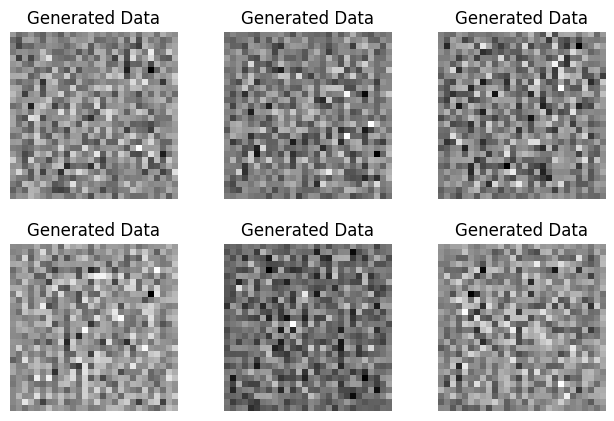

In [8]:
model.plot_imgs()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 478kB/s]
100%|██████████| 1.65M/1.65M

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ generator │ Generator │  357 K │ train │     0 │
│ 1 │ critic    │ Critic    │ 21.4 K │ train │     0 │
└───┴───────────┴───────────┴────────┴───────┴───────┘

Trainable params: 379 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 379 K                                                                                                
Total estimated model params size (MB): 1.517                                                                      
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

epoch 0

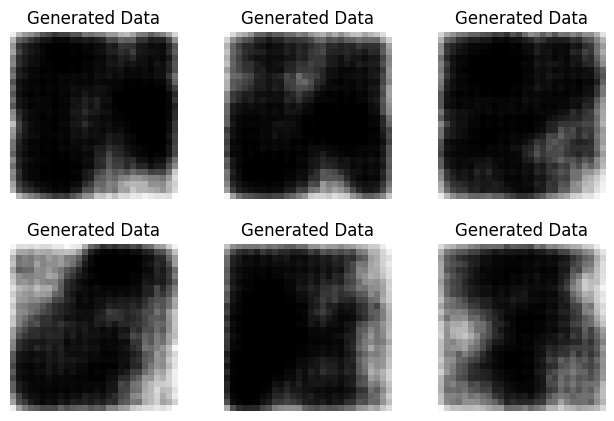

epoch 1

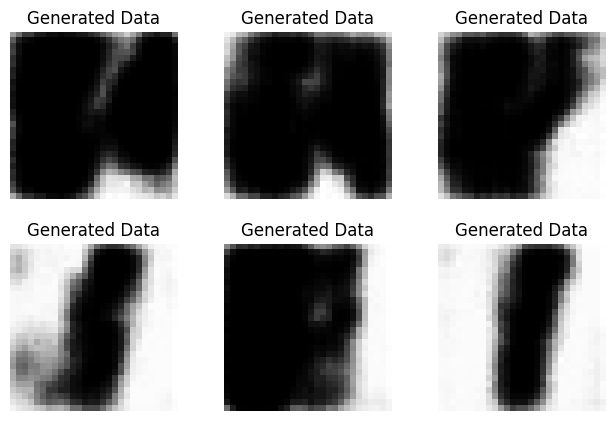

epoch 2

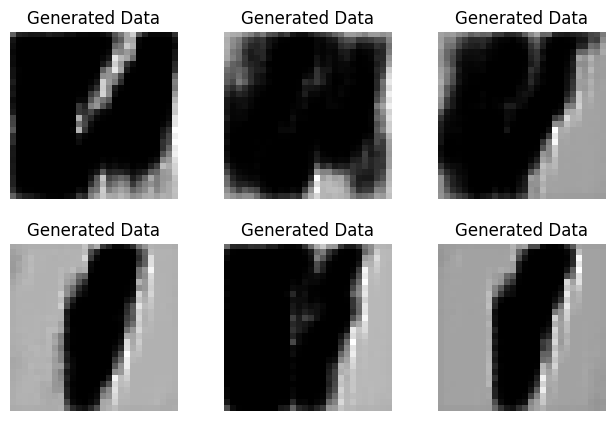

epoch 3

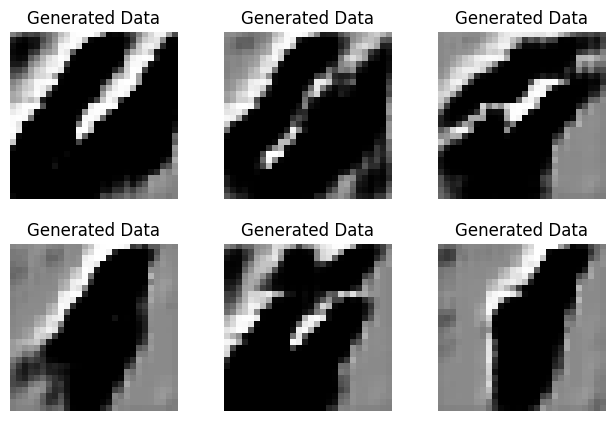

epoch 4

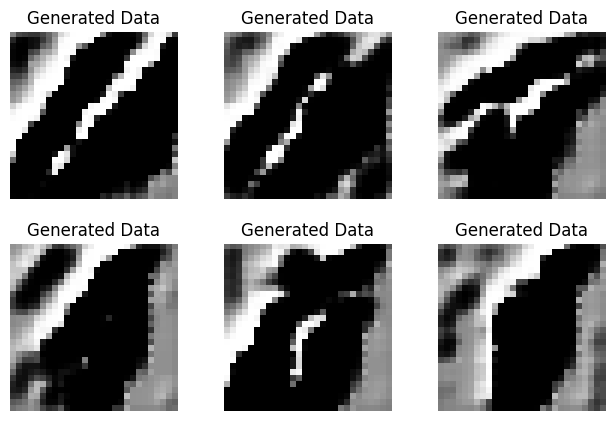

epoch 5

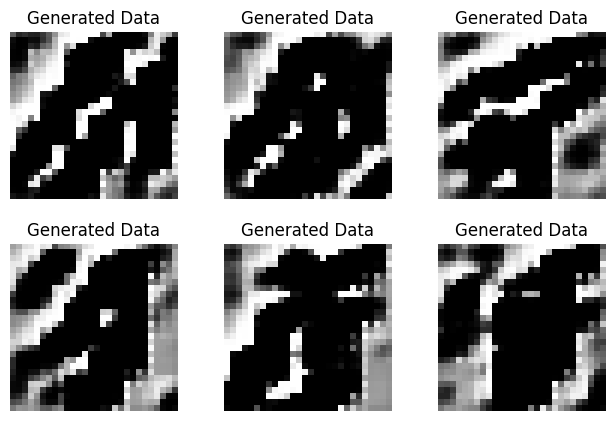

epoch 6

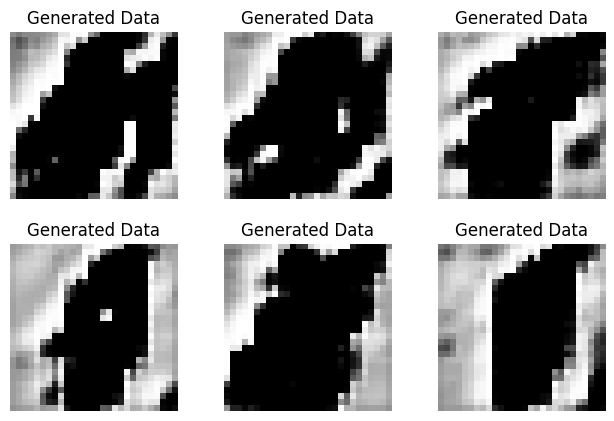

epoch 7

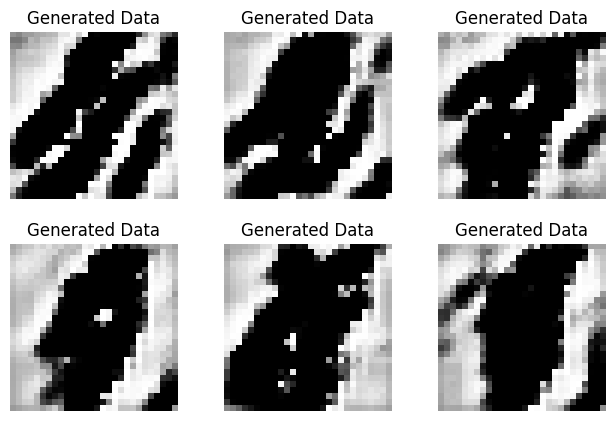

epoch 8

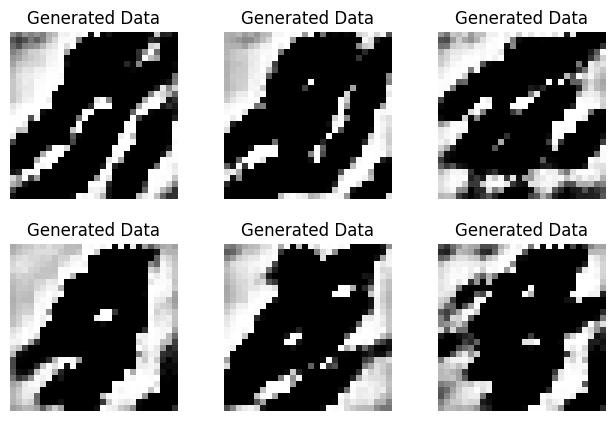

epoch 9

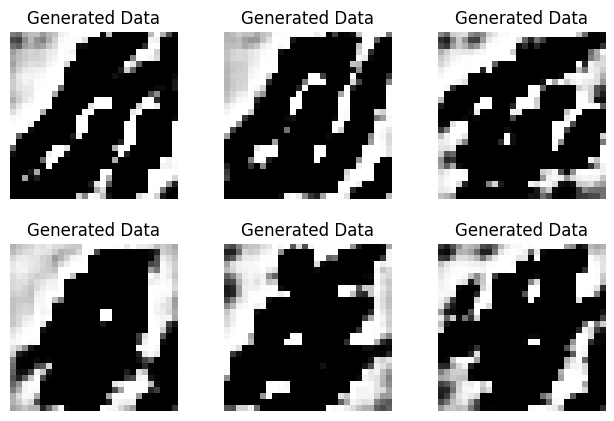

epoch 10

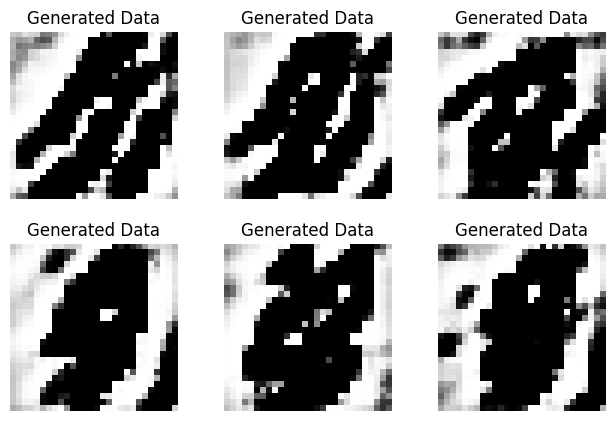

epoch 11

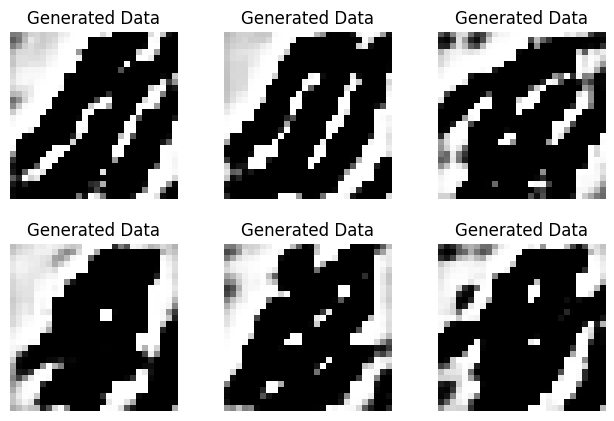

epoch 12

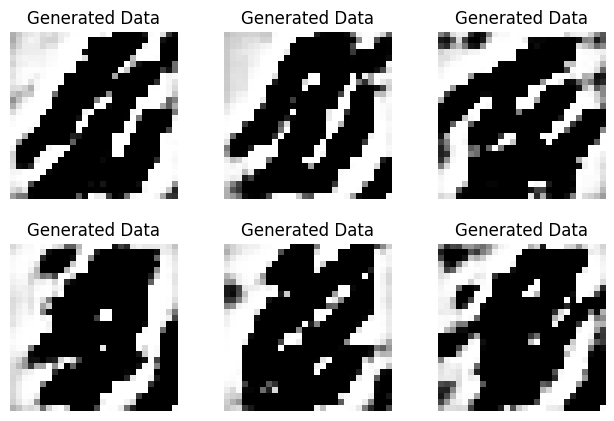

epoch 13

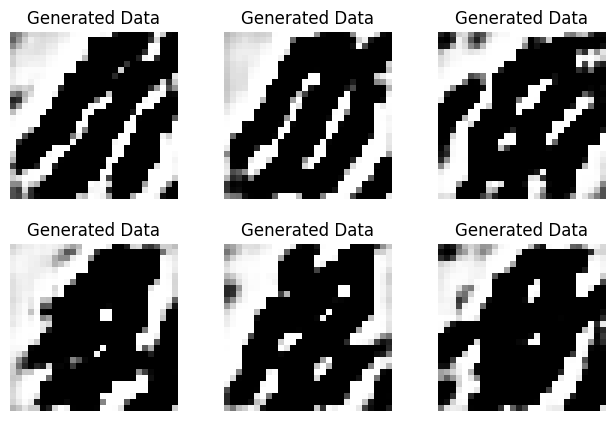

epoch 14

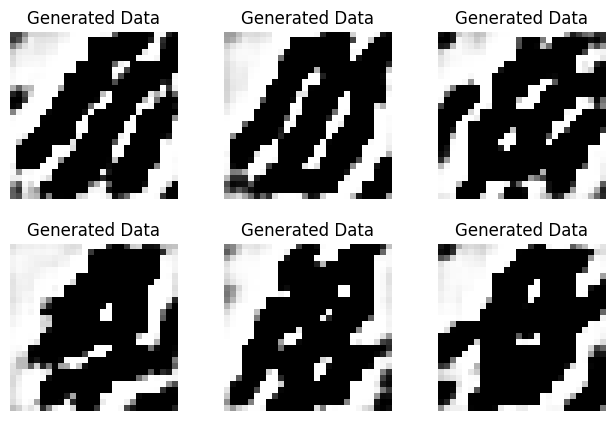

epoch 15

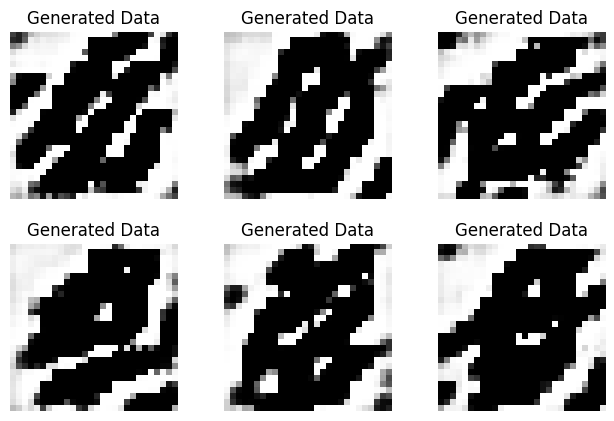

epoch 16

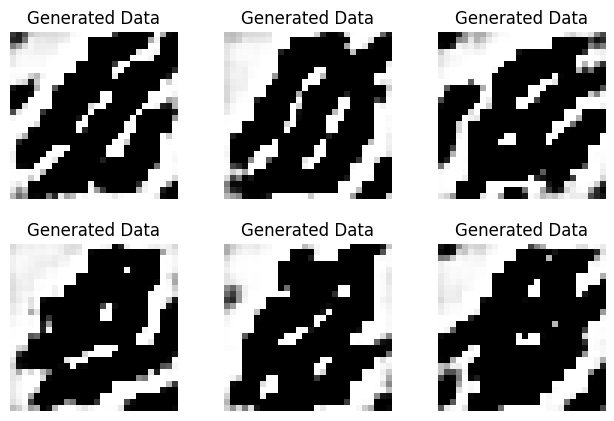

epoch 17

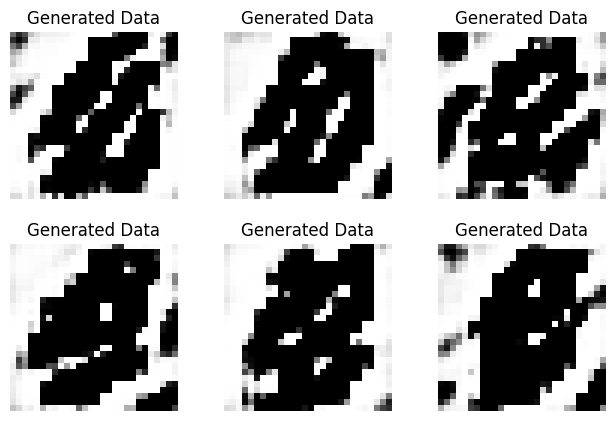

epoch 18

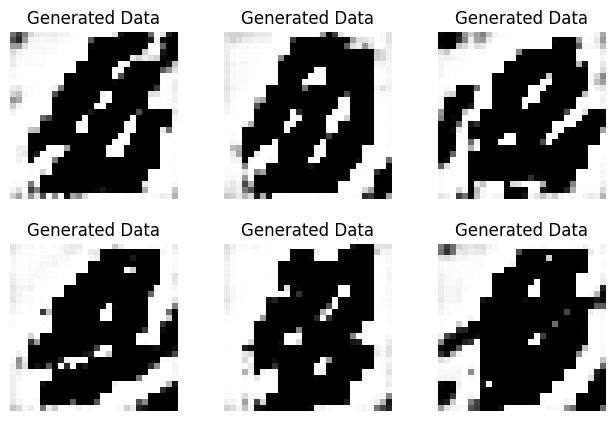

epoch 19

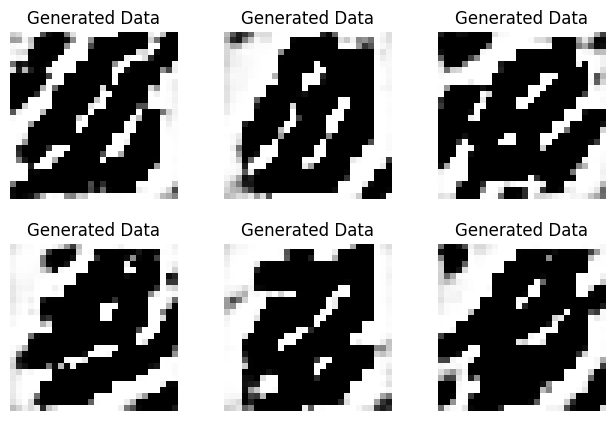

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


In [9]:
trainer = pl.Trainer(max_epochs=20, accelerator="auto", devices="auto")
trainer.fit(model, dm)